<a href="https://colab.research.google.com/github/anathayna/tcc/blob/main/tcc_fim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="orange">**TCC: Identificação do discurso de ódio em memes**</font>

O Google Colab é uma plataforma baseada em Jupyter Notebook que oferece um ambiente de execução em nuvem com recursos gratuitos de GPU e TPU, amplamente utilizado em projetos de aprendizado de máquina e ciência de dados.

Este notebook documenta a etapa de pré-processamento do banco de dados do trabalho de conclusão de curso, cujo objetivo é identificar e classificar discursos de ódio em memes por meio de técnicas de aprendizado de máquina multimodal.

# <font color="orange">**Sumário**</font>

1.   Bibliotecas e dependências
2.   Banco de dados
3.   Treinamento
4.   Avaliação
5.   Conclusão

## <font color="orange">1. Bibliotecas e dependências</font>

In [1]:
!pip install -q jsonlines
!pip install -q transformers
!pip install -q torchmetrics
!pip install -q scikit-fuzzy
!pip install -q ftfy regex tqdm
!pip install -q pytorch-lightning
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q scikit-learn matplotlib seaborn pandas Pillow ftfy

  Preparing metadata (setup.py) ... done


In [2]:
import os
import clip
import json
import copy
import time
import torch
import random
import shutil
import zipfile
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

from PIL import Image
from google.colab import drive
from transformers import CLIPModel
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPTokenizer
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.metrics import (roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay)

In [3]:
DATA_ROOT = "/content/drive/MyDrive/hateful_memes"

class Config:
    data_root        = DATA_ROOT
    image_size       = 224

    clip_model       = "openai/clip-vit-large-patch14"
    fusion           = "cross"

    map_dim          = 256
    num_map_layers   = 1
    num_pre_output   = 1
    drop_probs       = (0.1, 0.4, 0.2)

    w_image_loss     = 1.0
    w_text_loss      = 1.0

    batch_size       = 16
    lr               = 1e-4
    weight_decay     = 1e-4
    max_epochs       = 20
    grad_clip        = 0.1
    seed             = 42

    output_dir       = "/content/outputs"
    device           = "cuda" if torch.cuda.is_available() else "cpu"

Config = Config()
os.makedirs(Config.output_dir, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.seed)
print("✅ Configuração carregada")
print(f"   Fusão: {Config.fusion}")
print(f"   CLIP: {Config.clip_model}")

✅ Configuração carregada
   Fusão: cross
   CLIP: openai/clip-vit-large-patch14


## <font color="orange">2. Banco de dados</font>

O banco de dados utilizado para a identificação do discurso de ódio em memes é o **Hateful Memes** disponibilizado pela Meta no *Challenge Hateful Memes*, um banco de dados com mais de **10 mil** imagens de memes em inglês, que contêm conteúdo ofensivo relacionado a gênero, raça, religião, orientação sexual, classe social e outros tópicos.

E o conjunto de dados é composto pelas seguintes porcentagens:

- **40%** de memes de ódio multimodal (multimodal hate): memes em que tanto o texto quanto a imagem contribuem para a mensagem de ódio.

- **10%** de memes de ódio unimodal (unimodal hate): memes em que apenas uma das modalidades (texto ou imagem) é suficiente para transmitir o discurso de ódio.

- **20%** de memes com confusão de texto benigna (benign text confounder): memes em que o texto foi alterado para remover o discurso de ódio, mas a imagem ainda pode sugerir um significado ofensivo.

- **20%** de memes com confusão de imagem benigna (benign image confounder): memes em que a imagem foi alterada para remover o discurso de ódio, mas o texto ainda pode sugerir um significado ofensivo.

- **10%** de memes não odiosos aleatórios (random non-hateful): memes que não contêm discurso de ódio, escolhidos aleatoriamente.


Um **confundidor benigno** é, basicamente, uma alteração mínima feita em um meme (seja mudando o texto ou a imagem) que faz com que a classificação dele mude de “odioso” para “não odioso”. A alteração é a menor possível, justamente para garantir que a diferença entre o meme odioso e o benigno seja bem sutil e dependa de uma análise genuína das duas modalidades (texto+imagem).


![](https://drivendata-public-assets.s3.amazonaws.com/memes-overview.png)


**Figura 1:** Exemplo de meme utilizado na competição  
Fonte: DRIVENDATA (2020)

In [4]:
#@markdown Defina o caminho para o arquivo **.zip** do banco de dados do *Hateful Memes*.
#@markdown **exemplo:** `"/content/drive/MyDrive/hateful_memes.zip"`

PATH_TO_ZIP_FILE = '/content/drive/MyDrive/hateful_memes.zip' #@param {type:"string"}

#@markdown Defina o diretório base para extrair o banco de dados.
#@markdown **exemplo:** `"/content"`

HOME = '/content' #@param {type:"string"}

In [5]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
os.chdir(HOME)
os.getcwd()
os.environ['PYTHONPATH'] += ":/content/model/"

In [7]:
zip_path = PATH_TO_ZIP_FILE
extract_path = '/content/model/'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
img_dir = '/content/model/hateful_memes/img'

image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp']

image_count = 0
for filename in os.listdir(img_dir):
    if any(filename.lower().endswith(ext) for ext in image_extensions):
        image_count += 1

print(f"total de imagens: {image_count}")

total de imagens: 12140


- Pasta `img/` — contém as imagens (formato .png) correspondentes aos memes.
- Arquivos `.jsonl`:
  - **train.jsonl** — conjunto de treinamento, com rótulos disponíveis (0 = non-hateful, 1 = hateful)
  - **dev_seen.jsonl** — conjunto de validação (seen)
  - **dev_unseen.jsonl** — conjunto de validação (unseen), sem rótulos
  - **test_seen.jsonl** — conjunto de teste (seen)
  - **test_unseen.jsonl** — conjunto de teste (unseen), sem rótulos


In [9]:
import jsonlines

base_path = '/content/model/hateful_memes/'

def read_jsonl_to_dataframe(jsonl_path):
    data = []
    with jsonlines.open(jsonl_path) as reader:
        for obj in reader:
            data.append(obj)
    return pd.DataFrame(data)

df_train = read_jsonl_to_dataframe(os.path.join(base_path, "train.jsonl"))
df_dev_seen = read_jsonl_to_dataframe(os.path.join(base_path, "dev_seen.jsonl"))
df_dev_unseen = read_jsonl_to_dataframe(os.path.join(base_path, "dev_unseen.jsonl"))
df_test_seen = read_jsonl_to_dataframe(os.path.join(base_path, "test_seen.jsonl"))
df_test_unseen = read_jsonl_to_dataframe(os.path.join(base_path, "test_unseen.jsonl"))

df_train.head()

,id,img,label,text
0,42953,img/42953.png,0,its their character not their color that matters
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...
2,13894,img/13894.png,0,putting bows on your pet
3,37408,img/37408.png,0,i love everything and everybody! except for sq...
4,82403,img/82403.png,0,"everybody loves chocolate chip cookies, even h..."


In [10]:
print(f"Total entries in train.jsonl: {df_train.shape[0]}")
print(f"Total entries in dev_seen.jsonl: {df_dev_seen.shape[0]}")
print(f"Total entries in dev_unseen.jsonl: {df_dev_unseen.shape[0]}")
print(f"Total entries in test_seen.jsonl: {df_test_seen.shape[0]}")
print(f"Total entries in test_unseen.jsonl: {df_test_unseen.shape[0]}")

Total entries in train.jsonl: 8500
Total entries in dev_seen.jsonl: 500
Total entries in dev_unseen.jsonl: 540
Total entries in test_seen.jsonl: 1000
Total entries in test_unseen.jsonl: 2000


In [11]:
label_map = {0: 'non-hateful', 1: 'hateful'}
value_counts_df = df_train['label'].value_counts().reset_index()
value_counts_df.columns = ['label', 'count']
value_counts_df['%'] = (value_counts_df['count'] / value_counts_df['count'].sum() * 100).map('{:.2f}'.format)
value_counts_df['meaning'] = value_counts_df['label'].map(label_map)
display(value_counts_df.style.hide(axis='index').set_caption("df_train distribution"))

label,count,%,meaning
0,5481,64.48,non-hateful
1,3019,35.52,hateful


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


✅ Dataset carregado
   train: 8,500 amostras
   dev_seen: 500 amostras
   test_seen: 1,000 amostras
   dev_unseen: 540 amostras
   test_unseen: 2,000 amostras


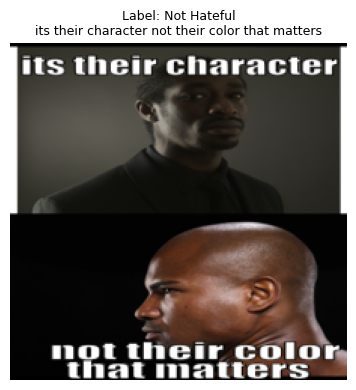

In [12]:
class HatefulMemesDataset(Dataset):
    def __init__(self, root, split="train", image_size=224):
        self.root       = root
        self.split      = split
        self.image_size = image_size

        jsonl_path = os.path.join(root, f"{split}.jsonl")
        with open(jsonl_path, "r") as f:
            self.samples = [json.loads(l) for l in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(os.path.join(self.root, s["img"])).convert("RGB")
        img = img.resize((self.image_size, self.image_size))
        return {
            "image": img,
            "text" : s["text"],
            "label": int(s.get("label", 0)),
            "id"   : int(s["id"]),
        }


class HatefulMemesPrep:
    """
    Tokeniza texto e processa imagem com CLIPProcessor.
    """
    def __init__(self, clip_model_name):
        self.processor = CLIPProcessor.from_pretrained(clip_model_name)
        self.tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)

    def __call__(self, batch):
        images  = [b["image"]  for b in batch]
        texts   = [b["text"]   for b in batch]
        labels  = torch.LongTensor([b["label"] for b in batch])
        ids     = [b["id"]     for b in batch]

        pv = self.processor(images=images, return_tensors="pt")["pixel_values"]
        tk = self.tokenizer(texts, padding=True, truncation=True,
                            max_length=77, return_tensors="pt")
        return {
            "pixel_values"  : pv,
            "input_ids"     : tk["input_ids"],
            "attention_mask": tk["attention_mask"],
            "labels"        : labels,
            "ids"           : ids,
        }


prep = HatefulMemesPrep(Config.clip_model)

data_root = base_path

ds_train = HatefulMemesDataset(data_root, "train", Config.image_size)
ds_dev_seen   = HatefulMemesDataset(data_root, "dev_seen", Config.image_size)
ds_test_seen  = HatefulMemesDataset(data_root, "test_seen",Config.image_size)
ds_dev_unseen   = HatefulMemesDataset(data_root, "dev_unseen", Config.image_size)
ds_test_unseen  = HatefulMemesDataset(data_root, "test_unseen",Config.image_size)

dl_train = DataLoader(ds_train, batch_size=Config.batch_size, shuffle=True,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_dev_seen   = DataLoader(ds_dev_seen,   batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_test_see  = DataLoader(ds_test_seen,  batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_dev_unseen   = DataLoader(ds_dev_unseen,   batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)
dl_test_unsee  = DataLoader(ds_test_unseen,  batch_size=Config.batch_size, shuffle=False,
                      num_workers=2, collate_fn=prep, pin_memory=True)

print(f"✅ Dataset carregado")
print(f"   train: {len(ds_train):,} amostras")
print(f"   dev_seen: {len(ds_dev_seen):,} amostras")
print(f"   test_seen: {len(ds_test_seen):,} amostras")
print(f"   dev_unseen: {len(ds_dev_unseen):,} amostras")
print(f"   test_unseen: {len(ds_test_unseen):,} amostras")

sample = ds_train[0]
plt.figure(figsize=(4,4))
plt.imshow(sample["image"])
plt.title(f"Label: {'Hateful' if sample['label']==1 else 'Not Hateful'}\n{sample['text'][:60]}",
          fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

## <font color="orange">3. Treinamento</font>

In [13]:
class HateCLIPper(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fusion          = cfg.fusion
        self.map_dim         = cfg.map_dim
        self.w_image_loss    = cfg.w_image_loss
        self.w_text_loss     = cfg.w_text_loss
        drop                 = cfg.drop_probs

        _clip = CLIPModel.from_pretrained(cfg.clip_model)
        self.image_encoder = copy.deepcopy(_clip.vision_model)
        self.text_encoder  = copy.deepcopy(_clip.text_model)
        img_hidden = self.image_encoder.config.hidden_size
        txt_hidden = self.text_encoder.config.hidden_size
        del _clip

        for p in self.image_encoder.parameters(): p.requires_grad_(False)
        for p in self.text_encoder.parameters():  p.requires_grad_(False)

        self.image_map = self._build_map(img_hidden, cfg.map_dim, cfg.num_map_layers, drop[0])
        self.text_map  = self._build_map(txt_hidden, cfg.map_dim, cfg.num_map_layers, drop[0])

        if   self.fusion == "align":       fused_dim = cfg.map_dim
        elif self.fusion == "concat":      fused_dim = cfg.map_dim * 2
        elif self.fusion == "cross":       fused_dim = cfg.map_dim ** 2   # FIM
        elif self.fusion == "align_concat":fused_dim = cfg.map_dim * 3
        else: raise ValueError(f"Fusão desconhecida: {self.fusion}")

        self.pre_output = self._build_pre_output(fused_dim, cfg.map_dim,
                                                 cfg.num_pre_output, drop[1], drop[2])
        self.output = nn.Linear(cfg.map_dim, 1)

        if self.w_image_loss > 0:
            self.pre_output_image = self._build_pre_output(cfg.map_dim, cfg.map_dim,
                                                           cfg.num_pre_output, drop[1], drop[2])
            self.output_image = nn.Linear(cfg.map_dim, 1)

        if self.w_text_loss > 0:
            self.pre_output_text = self._build_pre_output(cfg.map_dim, cfg.map_dim,
                                                          cfg.num_pre_output, drop[1], drop[2])
            self.output_text = nn.Linear(cfg.map_dim, 1)

        self.criterion = nn.BCEWithLogitsLoss()

    @staticmethod
    def _build_map(in_dim, out_dim, n_layers, drop_p):
        layers = [nn.Linear(in_dim, out_dim), nn.Dropout(drop_p)]
        for _ in range(1, n_layers):
            layers += [nn.ReLU(), nn.Linear(out_dim, out_dim), nn.Dropout(drop_p)]
        return nn.Sequential(*layers)

    @staticmethod
    def _build_pre_output(in_dim, map_dim, n_layers, drop1, drop2):
        layers = [nn.Dropout(drop1)]
        if n_layers >= 1:
            layers += [nn.Linear(in_dim, map_dim), nn.ReLU(), nn.Dropout(drop2)]
        for _ in range(1, n_layers):
            layers += [nn.Linear(map_dim, map_dim), nn.ReLU(), nn.Dropout(drop2)]
        return nn.Sequential(*layers)

    def _fuse(self, v, t):
        if   self.fusion == "align":
            return torch.mul(v, t)
        elif self.fusion == "concat":
            return torch.cat([v, t], dim=1)
        elif self.fusion == "cross":
            fim = torch.bmm(v.unsqueeze(2), t.unsqueeze(1))
            return fim.reshape(fim.shape[0], -1)
        elif self.fusion == "align_concat":
            return torch.cat([torch.mul(v, t), v, t], dim=1)

    def forward(self, batch, return_features=False):
        v = self.image_encoder(pixel_values=batch["pixel_values"]).pooler_output
        v = F.normalize(self.image_map(v), p=2, dim=1)
        t = self.text_encoder(input_ids=batch["input_ids"],
                              attention_mask=batch["attention_mask"]).pooler_output
        t = F.normalize(self.text_map(t), p=2, dim=1)

        fused   = self._fuse(v, t)
        logit_m = self.output(self.pre_output(fused)).squeeze(1)
        prob_m  = torch.sigmoid(logit_m)

        logit_img = self.output_image(self.pre_output_image(v)).squeeze(1) \
                    if self.w_image_loss > 0 else None
        logit_txt = self.output_text(self.pre_output_text(t)).squeeze(1) \
                    if self.w_text_loss  > 0 else None

        if return_features:
            return prob_m, logit_m, logit_img, logit_txt, v, t

        return prob_m, logit_m, logit_img, logit_txt

    def compute_loss(self, batch):
        prob_m, logit_m, logit_img, logit_txt = self(batch)
        y = batch["labels"].float()

        loss_m   = self.criterion(logit_m,   y)
        loss_img = self.criterion(logit_img, y) if logit_img is not None else 0.0
        loss_txt = self.criterion(logit_txt, y) if logit_txt is not None else 0.0

        total = loss_m + self.w_image_loss * loss_img + self.w_text_loss * loss_txt
        return total, loss_m, loss_img, loss_txt


model = HateCLIPper(Config).to(Config.device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modelo criado: {n_params:,} parâmetros treináveis")
print(f"   Fusão: {Config.fusion}  |  map_dim: {Config.map_dim}")

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo criado: 17,369,091 parâmetros treináveis
   Fusão: cross  |  map_dim: 256


In [14]:
drive_output_dir = "/content/drive/MyDrive/hateful_memes/outputs"
os.makedirs(drive_output_dir, exist_ok=True)
drive_ckpt_path = os.path.join(drive_output_dir, "best_model.pt")

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=Config.lr, weight_decay=Config.weight_decay
)

history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_acc": []}

def evaluate(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0.0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            probs, logit_m, logit_img, logit_txt = model(batch)
            y = batch["labels"].float()
            loss = model.criterion(logit_m, y)
            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds      = (all_probs >= 0.5).astype(int)
    return {
        "loss"  : total_loss / len(loader),
        "auroc" : roc_auc_score(all_labels, all_probs),
        "acc"   : accuracy_score(all_labels, preds),
        "f1"    : f1_score(all_labels, preds),
        "probs" : all_probs,
        "labels": all_labels,
    }

best_auroc    = 0.0
best_ckpt_path = os.path.join(Config.output_dir, "best_model.pt")

if os.path.exists(drive_ckpt_path):
    print(f"✅ Modelo já treinado encontrado no Drive.\nCarregando pesos de: {drive_ckpt_path}")
    model.load_state_dict(torch.load(drive_ckpt_path, map_location=Config.device))
    shutil.copy(drive_ckpt_path, best_ckpt_path)
else:
    print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val AUROC':>10} {'Val Acc':>9} {'Tempo':>8}")
    print("─" * 65)

    for epoch in range(1, Config.max_epochs + 1):
        model.train()
        t0     = time.time()
        ep_loss = 0.0

        for batch in dl_train:
            batch = {k: v.to(Config.device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            optimizer.zero_grad()
            total_loss, *_ = model.compute_loss(batch)
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), Config.grad_clip)
            optimizer.step()
            ep_loss += total_loss.item()

        train_loss = ep_loss / len(dl_train)
        val_metrics = evaluate(model, dl_dev_seen, Config.device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auroc"].append(val_metrics["auroc"])
        history["val_acc"].append(val_metrics["acc"])

        elapsed = time.time() - t0
        print(f"{epoch:>6} {train_loss:>12.4f} {val_metrics['loss']:>10.4f} "
              f"{val_metrics['auroc']:>10.4f} {val_metrics['acc']:>9.4f} {elapsed:>7.1f}s")

        if val_metrics["auroc"] > best_auroc:
            best_auroc = val_metrics["auroc"]
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"         ⭐ Melhor AUROC: {best_auroc:.4f} — checkpoint salvo")

    print(f"\n✅ Treino concluído -- Melhor Val AUROC: {best_auroc:.4f}")

    shutil.copy(best_ckpt_path, drive_ckpt_path)
    print(f"✅ Modelo salvo com sucesso no Google Drive:\n{drive_ckpt_path}")


 Epoch   Train Loss   Val Loss  Val AUROC   Val Acc    Tempo
─────────────────────────────────────────────────────────────────
     1       1.7329     0.7351     0.7352    0.6240   549.4s
         ⭐ Melhor AUROC: 0.7352 — checkpoint salvo
     2       1.3983     0.7579     0.7484    0.6400   561.4s
         ⭐ Melhor AUROC: 0.7484 — checkpoint salvo
     3       1.2833     0.7567     0.7626    0.6480   557.0s
         ⭐ Melhor AUROC: 0.7626 — checkpoint salvo
     4       1.2169     0.7821     0.7667    0.6500   562.6s
         ⭐ Melhor AUROC: 0.7667 — checkpoint salvo
     5       1.1662     0.7115     0.7792    0.6780   561.6s
         ⭐ Melhor AUROC: 0.7792 — checkpoint salvo
     6       1.1186     0.9035     0.7744    0.6540   560.4s
     7       1.0769     0.8745     0.7798    0.6820   560.7s
         ⭐ Melhor AUROC: 0.7798 — checkpoint salvo
     8       1.0305     0.8098     0.7918    0.6880   562.3s
         ⭐ Melhor AUROC: 0.7918 — checkpoint salvo
     9       0.9920     0.95

## <font color="orange">4. Avaliação</font>

  RESULTADO FINAL — test_seen
  AUROC    : 0.8240
  Accuracy : 0.7510
  F1-Score : 0.7167


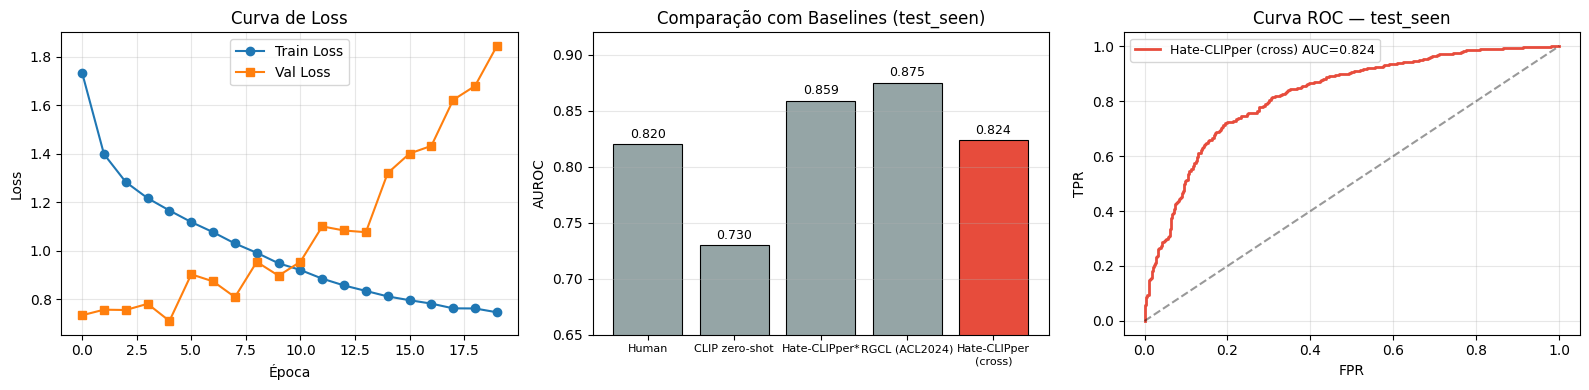


              precision    recall  f1-score   support

 Not Hateful       0.71      0.85      0.78       510
     Hateful       0.81      0.64      0.72       490

    accuracy                           0.75      1000
   macro avg       0.76      0.75      0.75      1000
weighted avg       0.76      0.75      0.75      1000



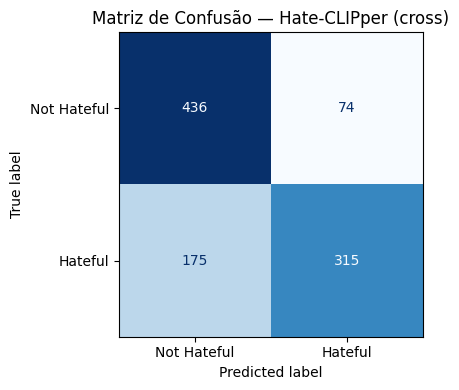

In [15]:
model.load_state_dict(torch.load(best_ckpt_path))
test_metrics = evaluate(model, dl_test_see, Config.device)

print("=" * 50)
print("  RESULTADO FINAL — test_seen")
print("=" * 50)
print(f"  AUROC    : {test_metrics['auroc']:.4f}")
print(f"  Accuracy : {test_metrics['acc']:.4f}")
print(f"  F1-Score : {test_metrics['f1']:.4f}")
print("=" * 50)

BASELINES = {
    "Human"          : 0.820,
    "CLIP zero-shot" : 0.730,
    "Hate-CLIPper*"  : 0.859,
    "RGCL (ACL2024)" : 0.875,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(history["train_loss"], label="Train Loss", marker="o")
ax.plot(history["val_loss"],   label="Val Loss",   marker="s")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Curva de Loss"); ax.legend(); ax.grid(True, alpha=0.3)


ax = axes[1]
names  = list(BASELINES.keys()) + [f"Hate-CLIPper\n({Config.fusion})"]
values = list(BASELINES.values()) + [test_metrics["auroc"]]
colors = ["#95a5a6"] * len(BASELINES) + ["#e74c3c"]
bars   = ax.bar(names, values, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylim(0.65, 0.92)
ax.set_ylabel("AUROC")
ax.set_title("Comparação com Baselines (test_seen)")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.tick_params(axis="x", labelsize=8)
ax.grid(True, alpha=0.3, axis="y")


ax = axes[2]
fpr, tpr, _ = roc_curve(test_metrics["labels"], test_metrics["probs"])
ax.plot(fpr, tpr, color="#e74c3c", lw=2,
        label=f"Hate-CLIPper ({Config.fusion}) AUC={test_metrics['auroc']:.3f}")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("Curva ROC — test_seen")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{Config.output_dir}/avaliacao_final.png", dpi=150)
plt.show()


print("\n" + classification_report(test_metrics["labels"],
                                   (test_metrics["probs"] >= 0.5).astype(int),
                                   target_names=["Not Hateful", "Hateful"]))
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(test_metrics["labels"],
                      (test_metrics["probs"] >= 0.5).astype(int))
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Hateful", "Hateful"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusão — Hate-CLIPper ({Config.fusion})")
plt.tight_layout()
plt.savefig(f"{Config.output_dir}/confusion_matrix.png", dpi=150)
plt.show()

## <font color="orange">5. Conclusão</font>

## <font color="orange">Teste</font>